# 2 · Model Development（模型開發）
**Outcome：** 用四個變項建立 EDR-18 的 XGBoost 模型，並做機率校準與風險分層。

**Methods：** Cross-validated predictions → ROC / Calibration → Youden 閾值 → Kaplan–Meier。

> 🧪 一樣使用虛構示範資料。

## 1. 載入資料與套件

In [1]:
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 140, 'font.size': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'figure.facecolor': 'white',
})
ACCENT = '#2f6df6'; ACCENT2 = '#f6862f'; GREY = '#9aa3b2'

df = pd.read_csv('../Data/synthetic_derivation.csv')
features = ['AJCC_Substage', 'LNR', 'Differentiation', 'PNI']
X, y = df[features].astype(float), df['edr_18m'].astype(int)
df.head()

,PatientID,AJCC_Substage,LNR,Differentiation,PNI,edr_18m,DFS_Months,DFS_Events
0,DEMO-01-0000,3,0.260,2,1,1,4.9,1
1,DEMO-01-0001,2,0.298,3,1,1,8.0,1
2,DEMO-01-0002,3,0.294,2,0,1,14.3,1
3,DEMO-01-0003,2,0.217,2,1,0,56.2,0
4,DEMO-01-0004,1,0.135,3,0,0,60.0,0


## 2. 交叉驗證的預測機率（避免過度樂觀）

In [2]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
base = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                     subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=42)
clf = CalibratedClassifierCV(base, method='isotonic', cv=3)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
oof = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')[:, 1]
print('out-of-fold 預測完成，n =', len(oof))

out-of-fold 預測完成，n = 620


## 3. ROC 曲線 + AUC → 存檔

AUC=0.639  Brier=0.196  cutoff=0.279


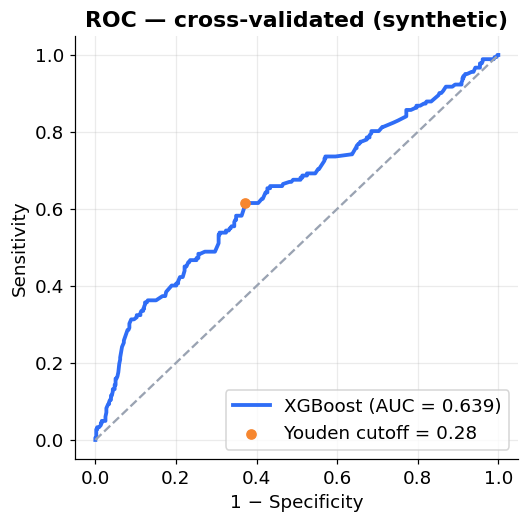

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score, brier_score_loss
fpr, tpr, thr = roc_curve(y, oof)
auc = roc_auc_score(y, oof)
j = np.argmax(tpr - fpr); cutoff = thr[j]
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot(fpr, tpr, color=ACCENT, lw=2.5, label=f'XGBoost (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], '--', color=GREY)
ax.scatter(fpr[j], tpr[j], color=ACCENT2, zorder=5, label=f'Youden cutoff = {cutoff:.2f}')
ax.set_xlabel('1 − Specificity'); ax.set_ylabel('Sensitivity')
ax.set_title('ROC — cross-validated (synthetic)', fontweight='bold'); ax.legend(loc='lower right')
os.makedirs('../Figures', exist_ok=True)
fig.savefig('../Figures/fig2_roc.png', bbox_inches='tight')
print(f'AUC={auc:.3f}  Brier={brier_score_loss(y, oof):.3f}  cutoff={cutoff:.3f}')

## 4. 校準曲線（預測機率 vs 實際）→ 存檔

已存檔 → ../Figures/fig3_calibration.png


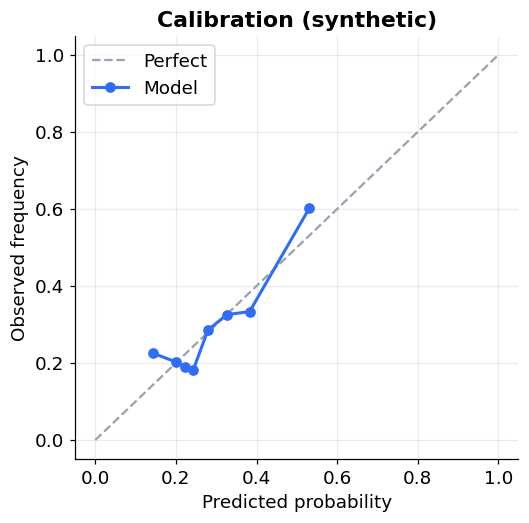

In [4]:
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y, oof, n_bins=8, strategy='quantile')
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0,1],[0,1], '--', color=GREY, label='Perfect')
ax.plot(mean_pred, frac_pos, 'o-', color=ACCENT, lw=2, label='Model')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title('Calibration (synthetic)', fontweight='bold'); ax.legend(loc='upper left')
fig.savefig('../Figures/fig3_calibration.png', bbox_inches='tight')
print('已存檔 → ../Figures/fig3_calibration.png')

## 5. 風險分層 + Kaplan–Meier（DFS）→ 存檔
用 Youden 閾值把病人分成高 / 低風險，畫無病存活曲線。

已存檔 → ../Figures/fig4_km_derivation.png


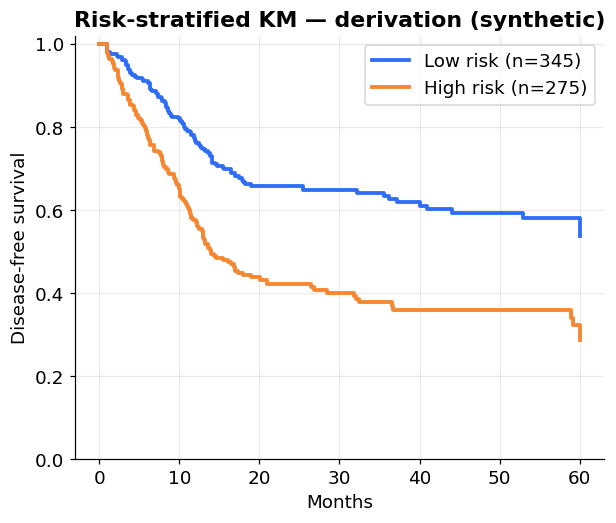

In [5]:
def km_curve(time, event):
    order = np.argsort(time); t = np.asarray(time)[order]; e = np.asarray(event)[order]
    uniq = np.unique(t); surv = 1.0; xs=[0]; ys=[1.0]; n = len(t)
    at_risk = n
    for ut in uniq:
        d = np.sum((t == ut) & (e == 1)); atr = np.sum(t >= ut)
        if atr > 0: surv *= (1 - d/atr)
        xs.append(ut); ys.append(surv)
    return np.array(xs), np.array(ys)

df['risk'] = np.where(oof >= cutoff, 'High risk', 'Low risk')
fig, ax = plt.subplots(figsize=(6.2, 5))
for grp, col in [('Low risk', ACCENT), ('High risk', ACCENT2)]:
    sub = df[df.risk == grp]
    xs, ys = km_curve(sub['DFS_Months'], sub['DFS_Events'])
    ax.step(xs, ys, where='post', color=col, lw=2.5, label=f'{grp} (n={len(sub)})')
ax.set_xlabel('Months'); ax.set_ylabel('Disease-free survival'); ax.set_ylim(0, 1.02)
ax.set_title('Risk-stratified KM — derivation (synthetic)', fontweight='bold'); ax.legend()
fig.savefig('../Figures/fig4_km_derivation.png', bbox_inches='tight')
print('已存檔 → ../Figures/fig4_km_derivation.png')

## 6. 匯出績效表到 `../Tables/` 並存模型

In [6]:
from sklearn.metrics import confusion_matrix
pred = (oof >= cutoff).astype(int)
tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
metrics = pd.DataFrame({'Metric': ['AUC','Brier','Sensitivity','Specificity','PPV','NPV','Cutoff'],
    'Value': [round(auc,3), round(brier_score_loss(y,oof),3), round(tp/(tp+fn),3),
              round(tn/(tn+fp),3), round(tp/(tp+fp),3), round(tn/(tn+fn),3), round(cutoff,3)]})
os.makedirs('../Tables', exist_ok=True)
metrics.to_csv('../Tables/table1_performance.csv', index=False)
import joblib; clf.fit(X, y); joblib.dump({'model': clf, 'features': features, 'cutoff': float(cutoff)},
    '../Data/demo_model.joblib')
print('已存檔 → ../Tables/table1_performance.csv  與  ../Data/demo_model.joblib')
metrics

已存檔 → ../Tables/table1_performance.csv  與  ../Data/demo_model.joblib


,Metric,Value
0,AUC,0.639
1,Brier,0.196
2,Sensitivity,0.615
3,Specificity,0.628
4,PPV,0.407
5,NPV,0.797
6,Cutoff,0.279


## ✅ 小結
模型、閾值、所有圖表的「產生程式碼」都留在 Notebook 裡。
Reviewer 要求修改時 → 改一格、重跑、結果就重現了。